# Data Preparation Summary

1.   Converted date variables into datetime format
2.   Created additional features
3.   Assess outliers condition


For better visualisation, encoding and standardisation are **not** performed. There are outliers in 3 variables, they are remained in the exported dataset to capture full image of purchase behaviour.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Optional display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving E Commerce Customer Insights and Churn Dataset.csv to E Commerce Customer Insights and Churn Dataset.csv


In [3]:
df = pd.read_csv('E Commerce Customer Insights and Churn Dataset.csv')
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,1/7/2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12/8/2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,6/10/2023,9/4/2023,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12/9/2020,9/14/2024,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [4]:
print("Shape:", df.shape)
df.info()
df.describe()
df.describe(include='object')

print("\nMissing Values:\n", df.isnull().sum())

Shape: (2000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2000 non-null   object 
 1   customer_id          2000 non-null   object 
 2   age                  2000 non-null   int64  
 3   product_id           2000 non-null   object 
 4   country              2000 non-null   object 
 5   signup_date          2000 non-null   object 
 6   last_purchase_date   2000 non-null   object 
 7   cancellations_count  2000 non-null   int64  
 8   subscription_status  2000 non-null   object 
 9   order_date           2000 non-null   object 
 10  unit_price           2000 non-null   float64
 11  quantity             2000 non-null   int64  
 12  purchase_frequency   2000 non-null   int64  
 13  preferred_category   2000 non-null   object 
 14  product_name         2000 non-null   object 
 15  category            

# 1. Convert date columns (objectType) to datetime

In [5]:
date_cols = ['signup_date', 'order_date', 'last_purchase_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].dtypes

,0
signup_date,datetime64[ns]
order_date,datetime64[ns]
last_purchase_date,datetime64[ns]


In [6]:
# Check whether the dataset is transaction-level or already customer-level
print("Total rows:", len(df))
print("Unique customer_id:", df['customer_id'].nunique())
print("Unique order_id:", df['order_id'].nunique())
print("Unique product_id:", df['product_id'].nunique())

Total rows: 2000
Unique customer_id: 2000
Unique order_id: 2000
Unique product_id: 2000


This shows that every customer only has one transaction record, the item bought by customer is also unique in every transaction.

# 2. Create additional features

## 2.1 RFM model

* **Recency** = the number of days since the customer’s last purchase.
* **Frequency** = existing purchase frequency variable.
* **Monetary** = derived from unit price multiplied by quantity.

In [7]:
# Spending
df['order_amount'] = df['unit_price'] * df['quantity']

# Reference date
reference_date = df['last_purchase_date'].max() + pd.Timedelta(days=1)

# RFM features
df['recency_days'] = (reference_date - df['last_purchase_date']).dt.days
df['frequency'] = df['purchase_frequency']
df['monetary'] = df['order_amount']

#drop 'purchase_frequency' column
df.drop(columns=['purchase_frequency'], inplace=True)

## 2.2 Additional Features

Additional behavioural and engagement variables were engineered to enhance churn prediction.
These include tenure days, average order value,purchase intensity, inactivity ratio, and cancellation rate.

In [8]:
# 2.2.1 Disclose customer lifecycle
df['tenure_days'] = (reference_date - df['signup_date']).dt.days

df['avg_order_value'] = np.where(
    df['frequency'] > 0,
    df['monetary'] / df['frequency'],
    0
)

# 2.2.2 Engagement
df['purchase_intensity'] = np.where(
    df['tenure_days'] > 0,
    df['frequency'] / df['tenure_days'],
    0
)
df['inactivity_ratio'] = np.where(
    df['tenure_days'] > 0,
    df['recency_days'] / df['tenure_days'],
    0
)

# 3. Check Outlier

In [9]:
# Non numerical columns
cat_cols = df.select_dtypes(include='object').columns
# Number of unique values
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# Check unique values
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())

# Value counts
for col in cat_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())

order_id: 2000 unique values
customer_id: 2000 unique values
product_id: 2000 unique values
country: 6 unique values
subscription_status: 3 unique values
preferred_category: 5 unique values
product_name: 40 unique values
category: 5 unique values
gender: 3 unique values

order_id:
['ORD5000' 'ORD5001' 'ORD5002' ... 'ORD6997' 'ORD6998' 'ORD6999']

customer_id:
['CUST1000' 'CUST1001' 'CUST1002' ... 'CUST2997' 'CUST2998' 'CUST2999']

product_id:
['PROD200' 'PROD201' 'PROD202' ... 'PROD2197' 'PROD2198' 'PROD2199']

country:
['Canada' 'USA' 'Pakistan' 'India' 'Germany' 'UK']

subscription_status:
['active' 'cancelled' 'paused']

preferred_category:
['Sports' 'Electronics' 'Clothing' 'Home' 'Beauty']

product_name:
['Football' 'Refrigerator' 'Hoodie' 'Conditioner' 'Smartwatch' 'Tablet'
 'Jacket' 'Nail Polish' 'Camera' 'Dumbbells' 'Headphones' 'Vacuum Cleaner'
 'Perfume' 'Cycling Helmet' 'Face Wash' 'Cricket Bat' 'Sneakers' 'Dress'
 'Smartphone' 'Lipstick' 'T-Shirt' 'Tennis Racket' 'Sofa' 'La

* `Country`, `Preferred_category`, and `Product_category` are balanced distribution, with no single category dominating or appearing as a "rare event."

* 3.4% response as "others" in `gender`, not treated as outlier

In [10]:
# Select numerical columns for outlier detection
num_cols = [
    'age', 'quantity', 'unit_price',
    'frequency', 'monetary',
    'recency_days', 'tenure_days',
    'avg_order_value', 'purchase_intensity'
]

df[num_cols].head()

,age,quantity,unit_price,frequency,monetary,recency_days,tenure_days,avg_order_value,purchase_intensity
0,39,5,78.21,37,391.05,912,1687,10.568919,0.021932
1,61,8,64.02,35,512.16,1352,1767,14.633143,0.019808
2,26,2,604.14,44,1208.28,717,803,27.460909,0.054795
3,54,4,84.66,1,338.64,548,753,338.640000,0.001328
4,50,7,62.66,35,438.62,341,1716,12.532000,0.020396


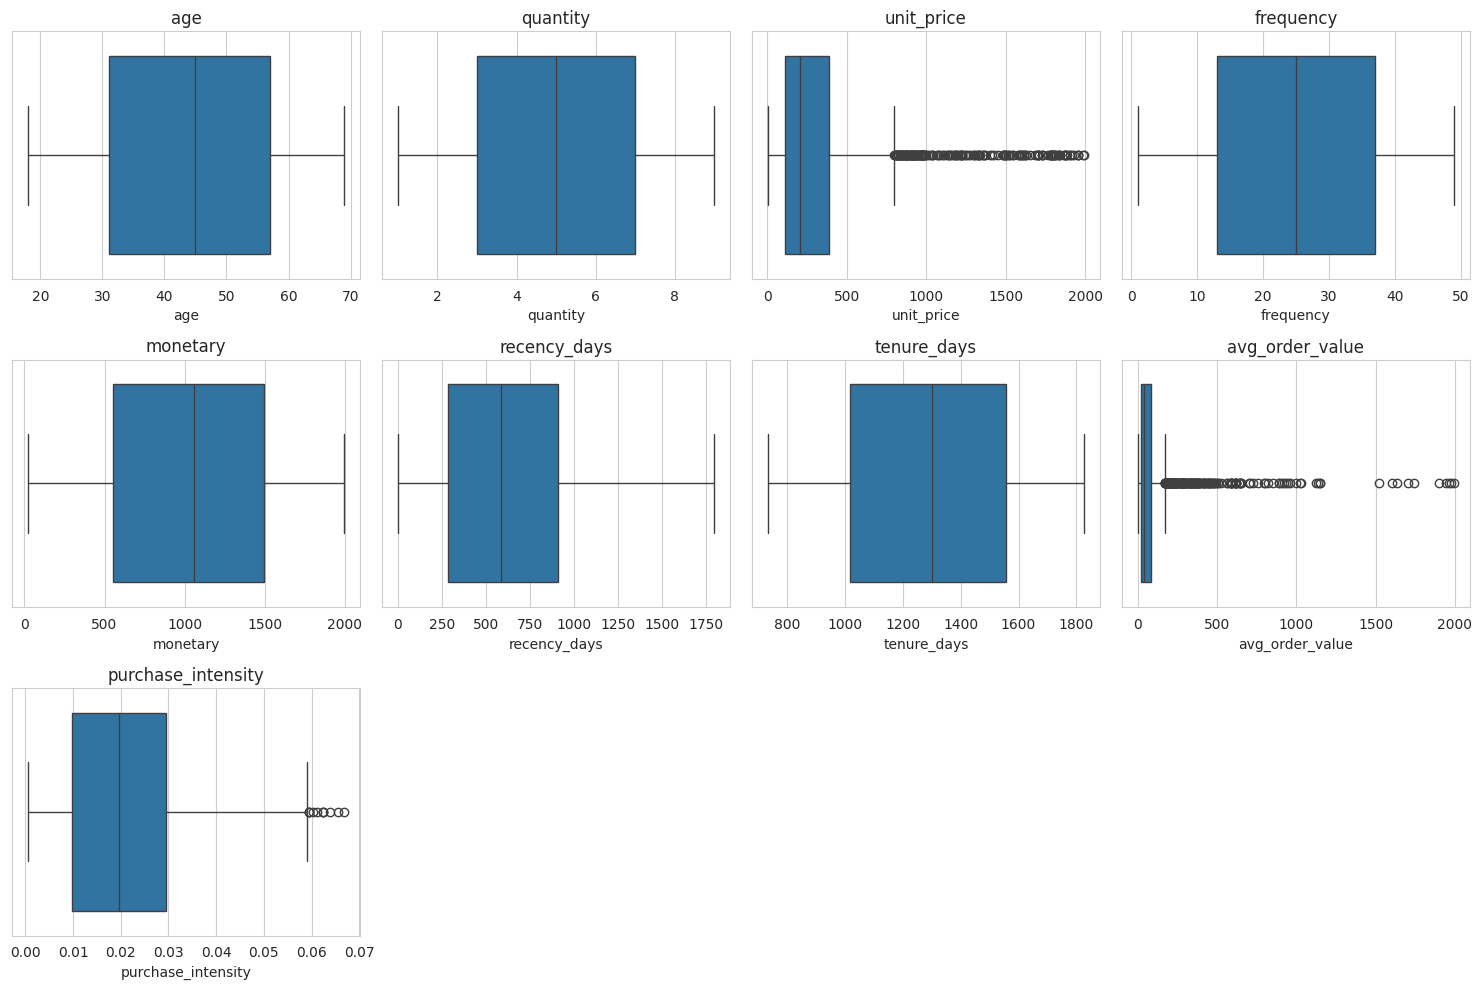

In [11]:
# Boxplots for outlier detection
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = len(outliers)

    return outlier_summary

# Run detection
outliers = detect_outliers_iqr(df, num_cols)

print("Outlier count per column:")
print(outliers)

Outlier count per column:
{'age': 0, 'quantity': 0, 'unit_price': 186, 'frequency': 0, 'monetary': 0, 'recency_days': 0, 'tenure_days': 0, 'avg_order_value': 215, 'purchase_intensity': 11}


* age, quantity, frequency, and tenure_days show relatively balanced distributions, requiring no further adjustment.

* unit_price, avg_order_value, purchase_intensity display strong right skewness and the presence of outliers.

    We remain unit_price and avg_order_value records, they could be representing premium segments. They wouldn't affect modeling if we choose to use tree-based models.

    The 11 outliers in purchase_intensity (<1%) are negligible.

# Final quality check

In [13]:
print("="*60)
print("Data Quality Report")
print("="*60)

# 1. Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct%': missing_pct.round(2)
})

missing_df = missing_df[missing_df['missing_count'] > 0]

print("\nMissing Values per variable:")
print(missing_df if not missing_df.empty else "No missing values")

# 2. Duplicate check
dup_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {dup_count}")

# 3. Unique counts (key categorical variables)
cat_cols = df.select_dtypes(include='object').columns

print("\nCategorical Variable Summary:")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# 4. Dataset structure
print("\nDataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 5. Customer uniqueness (VERY IMPORTANT ⭐)
unique_customers = df['customer_id'].nunique()
print(f"\nCustomer Count: {unique_customers}/{len(df)}")

if unique_customers == len(df):
    print("✓ Dataset is at customer-level (no duplicates per customer)")
else:
    print("⚠ Multiple rows per customer detected")

# 6. Final check summary
print("\nOverall Data Quality Status:")
if missing_df.empty and dup_count == 0:
    print("✓ Clean dataset — no missing values and no duplicates")
else:
    print("⚠ Data requires further cleaning")

print("="*60)

Data Quality Report

Missing Values per variable:
No missing values

Duplicate Rows: 0

Categorical Variable Summary:
order_id: 2000 unique values
customer_id: 2000 unique values
product_id: 2000 unique values
country: 6 unique values
subscription_status: 3 unique values
preferred_category: 5 unique values
product_name: 40 unique values
category: 5 unique values
gender: 3 unique values

Dataset Shape:
Rows: 2000, Columns: 24

Customer Count: 2000/2000
✓ Dataset is at customer-level (no duplicates per customer)

Overall Data Quality Status:
✓ Clean dataset — no missing values and no duplicates


In [14]:
# Export cleaned dataset
df.to_csv("cleaned_ecommerce_churn_dataset.csv", index=False)